# 04 — Bayesian Shrinkage of Graduation Rates

**Chapter 6 companion.** A 100% graduation rate from a cohort of 6 and a 100% rate
from a cohort of 600 are not the same evidence. Rank institutions on raw rates and
the top and bottom of the list fill with small cohorts, because small samples have
large sampling variance. This is the problem AstroML treats with hierarchical
models, and empirical-Bayes shrinkage is the standard remedy.

The notebook tests the method rather than assuming it works. Each institution's
2015-cohort estimate is used to predict the same institution's 2017-cohort rate,
and the raw and shrunk estimates are scored against it.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet` |
| Estimate | 2015 bachelor's cohort, completion within 150% of normal time: `GR200_23` `BANC150` / `BAAC150` |
| Holdout | 2017 bachelor's cohort, 6-year rate: `DRVGR2023` `GBA6RTT` |
| Methods | Funnel plot, beta-binomial MLE by control, posterior means and credible intervals, rank stability, out-of-cohort validation |
| Output | `data/analytic/shrunk_grad_rates.parquet` (used by notebook 10) |

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. Recompute the rate and check it against the published value

Recomputing the rate from counts, instead of using the published percentage, keeps
the numerator and denominator the model needs. The published `BAGR150` is an integer,
so agreement is checked to within one point. An exact-equality check would fail on
rounding alone.

In [3]:
ba = inst[(inst["ICLEVEL"] == 1) & (inst["BAAC150"] > 0) & inst["BANC150"].notna()].copy()
ba["k"] = ba["BANC150"].astype(int)
ba["n"] = ba["BAAC150"].astype(int)
ba["raw"] = ba["k"] / ba["n"]

diff = (100 * ba["raw"] - ba["BAGR150"]).abs()
print(f"{len(ba):,} four-year institutions with a 2015 bachelor's cohort")
print(f"recomputed vs published: max |difference| = {diff.max():.2f} points; "
      f"{(diff > 0.5).sum()} differ by more than rounding (> 0.5)")
assert (diff <= 1).all(), "recomputed rate disagrees with BAGR150 by more than a point"
ba.loc[diff > 0.5, ["INSTNM", "k", "n", "BAGR150"]].assign(recomputed=100 * ba["raw"])

1,965 four-year institutions with a 2015 bachelor's cohort
recomputed vs published: max |difference| = 0.50 points; 2 differ by more than rounding (> 0.5)


,INSTNM,k,n,BAGR150,recomputed
1259,The Southern Baptist Theological Seminary,49,121,41.000,40.496
2026,Albany College of Pharmacy and Health Sciences,23,40,58.000,57.500


The two flagged institutions sit on or near a .5 boundary: 40.496 is published as 41,
and 57.5 is rounded up to 58. The first suggests NCES rounds from an intermediate
value rather than from the two published counts. A one-point gap is harmless, but it
is why a validation rule on derived rates needs a tolerance.

## 2. The funnel plot

Under a single common rate `p0`, an institution's observed rate would fall within
`p0 +/- z * sqrt(p0 (1 - p0) / n)`. The funnel narrows with cohort size. If rates
were binomial noise around one value, about 0.2% of institutions would fall outside
the 99.8% limits.

pooled rate 0.641; outside 99.8% limits: 65.4% (0.2% expected under a common rate)


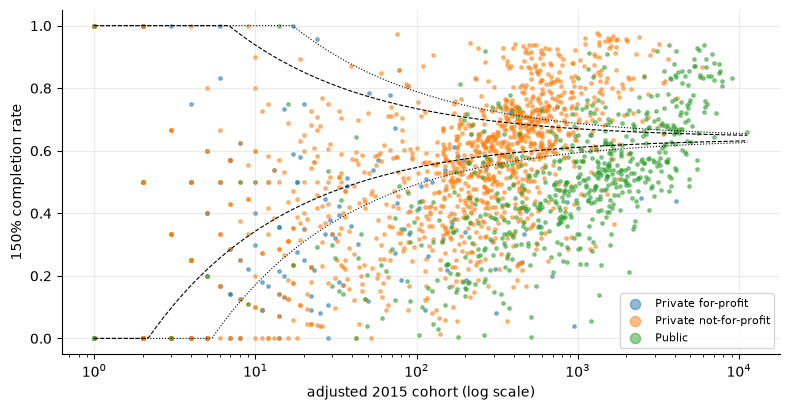

In [4]:
p0 = ba["k"].sum() / ba["n"].sum()
n_grid = np.logspace(0, np.log10(ba["n"].max()), 300)
se = np.sqrt(p0 * (1 - p0) / n_grid)
outside = (np.abs(ba["raw"] - p0) > 3.09 * np.sqrt(p0 * (1 - p0) / ba["n"])).mean()
print(f"pooled rate {p0:.3f}; outside 99.8% limits: {outside:.1%} (0.2% expected under a common rate)")

fig, ax = plt.subplots(figsize=(8, 4.2))
for label, g in ba.groupby("CONTROL_LABEL"):
    ax.scatter(g["n"], g["raw"], s=6, alpha=0.5, label=label)
for z, style in ((1.96, "--"), (3.09, ":")):
    ax.plot(n_grid, np.clip(p0 + z * se, 0, 1), "k", ls=style, lw=0.8)
    ax.plot(n_grid, np.clip(p0 - z * se, 0, 1), "k", ls=style, lw=0.8)
ax.set(xscale="log", xlabel="adjusted 2015 cohort (log scale)", ylabel="150% completion rate")
ax.legend(markerscale=3, fontsize=8)
save("04_funnel")

Far more institutions fall outside the limits than chance allows, so institutions
genuinely differ. A single pooled rate is the wrong prior. The beta-binomial model
represents that between-institution variation explicitly: true rates follow a
Beta(a, b) distribution, and each observed count is binomial given its true rate.

## 3. Fit the prior within control

Institutions are shrunk toward the mean of their own control, not the national mean.
The prior strength `a + b` is the number of students the prior is worth: a cohort of
that size lands halfway between its raw rate and the group mean.

In [5]:
priors = {}
for control, g in ba.groupby("CONTROL_LABEL"):
    a, b = iu.fit_beta_binomial(g["k"], g["n"])
    priors[control] = (a, b)

pd.DataFrame(
    [{"control": c, "institutions": int((ba["CONTROL_LABEL"] == c).sum()), "a": a, "b": b,
      "prior mean": a / (a + b), "prior strength (a + b)": a + b,
      "prior SD": np.sqrt(a * b / ((a + b) ** 2 * (a + b + 1)))}
     for c, (a, b) in priors.items()]
)

,control,institutions,a,b,prior mean,prior strength (a + b),prior SD
0,Private for-profit,144,1.649,2.937,0.360,4.586,0.203
1,Private not-for-profit,1208,2.601,2.088,0.555,4.689,0.208
2,Public,613,2.719,2.682,0.503,5.401,0.198


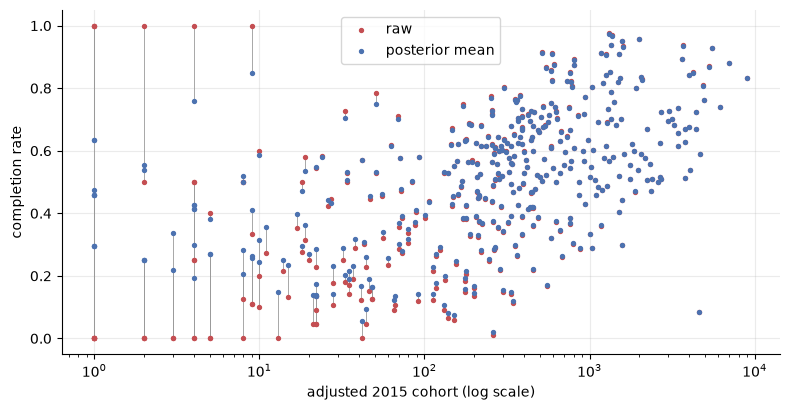

In [6]:
parts = []
for control, g in ba.groupby("CONTROL_LABEL"):
    a, b = priors[control]
    parts.append(iu.shrink(g["k"], g["n"], a, b, level=0.9))
ba = ba.join(pd.concat(parts))

fig, ax = plt.subplots(figsize=(8, 4.2))
sample = ba.sample(400, random_state=SEED)
for _, r in sample.iterrows():
    ax.plot([r["n"], r["n"]], [r["raw_rate"], r["post_mean"]], color="#999999", lw=0.6)
ax.scatter(sample["n"], sample["raw_rate"], s=8, color="#C44E52", label="raw", zorder=3)
ax.scatter(sample["n"], sample["post_mean"], s=8, color="#4C72B0", label="posterior mean", zorder=3)
ax.set(xscale="log", xlabel="adjusted 2015 cohort (log scale)", ylabel="completion rate")
ax.legend()
save("04_shrinkage_arrows")

The fitted priors are weak, worth about five students each, because rates vary so
much between institutions. A weak prior means shrinkage matters only for small
cohorts. Each grey line runs from an institution's raw rate to its posterior mean.
Cohorts of a handful of students move a long way; cohorts of hundreds barely move,
because their own data dominates the posterior (`weight = n / (n + a + b)`).

The prior means sit below the pooled rate of the funnel plot. The pooled rate
weights every student; the prior describes the typical institution, and small
institutions graduate fewer of their students, the same size pattern notebook 03
found for retention.

## 4. What shrinkage does to rankings

In [7]:
top_raw = ba.nlargest(10, "raw_rate")
top_post = ba.nlargest(10, "post_mean")
print(f"median cohort in raw top 10:       {top_raw['n'].median():,.0f}")
print(f"median cohort in posterior top 10: {top_post['n'].median():,.0f}")
print(f"institutions in both lists: {len(set(top_raw.index) & set(top_post.index))}")
top_post[["INSTNM", "CONTROL_LABEL", "n", "raw_rate", "post_mean", "post_lo", "post_hi"]]

median cohort in raw top 10:       1
median cohort in posterior top 10: 1,634
institutions in both lists: 0


,INSTNM,CONTROL_LABEL,n,raw_rate,post_mean,post_lo,post_hi
1968,Princeton University,Private not-for-profit,1316,0.976,0.974,0.967,0.981
601,Yale University,Private not-for-profit,1362,0.969,0.968,0.960,0.975
1453,Harvard University,Private not-for-profit,1658,0.967,0.966,0.959,0.973
2867,University of Pennsylvania,Private not-for-profit,2381,0.962,0.961,0.955,0.968
1470,Massachusetts Institute of Technology,Private not-for-profit,1106,0.962,0.960,0.950,0.969
877,University of Chicago,Private not-for-profit,1535,0.959,0.958,0.949,0.966
2322,Duke University,Private not-for-profit,1745,0.959,0.958,0.949,0.965
1060,University of Notre Dame,Private not-for-profit,2002,0.959,0.958,0.950,0.965
2942,Brown University,Private not-for-profit,1609,0.958,0.957,0.949,0.965
3683,Stanford University,Private not-for-profit,1719,0.955,0.954,0.946,0.962


In [8]:
top_raw[["INSTNM", "CONTROL_LABEL", "n", "raw_rate", "post_mean", "post_lo", "post_hi"]]

,INSTNM,CONTROL_LABEL,n,raw_rate,post_mean,post_lo,post_hi
224,Haven University,Private not-for-profit,4,1.000,0.760,0.502,0.947
314,Humphreys University-Stockton and Modesto Camp...,Private not-for-profit,2,1.000,0.688,0.382,0.926
721,St. John Vianney College Seminary,Private not-for-profit,9,1.000,0.847,0.668,0.968
996,Saint Anthony College of Nursing,Private not-for-profit,1,1.000,0.633,0.300,0.909
1087,Divine Word College,Private not-for-profit,1,1.000,0.633,0.300,0.909
1177,Kansas Christian College,Private not-for-profit,1,1.000,0.633,0.300,0.909
1793,Stevens-The Institute of Business & Arts,Private for-profit,6,1.000,0.723,0.483,0.912
1866,Summit Christian College,Private not-for-profit,1,1.000,0.633,0.300,0.909
1945,Eastwick College-Ramsey,Private for-profit,1,1.000,0.474,0.160,0.799
2025,Bryant & Stratton College-Albany,Private not-for-profit,1,1.000,0.633,0.300,0.909


## 5. Does shrinkage predict better? An out-of-cohort test

A later cohort at the same institution is a fair test. If shrinkage only pulled
estimates toward an arbitrary centre, it would predict the 2017-cohort rate worse
than the raw 2015 rate. If it removes sampling noise, it should predict better, and
the gain should be concentrated in small cohorts, where the noise is.

In [9]:
test = ba.dropna(subset=["GBA6RTT"]).copy()
test["target"] = test["GBA6RTT"] / 100
test["cohort band"] = pd.cut(test["n"], [0, 25, 50, 100, 250, 1000, np.inf],
                             labels=["<25", "25-49", "50-99", "100-249", "250-999", "1000+"], right=False)


def rmse(g, col):
    return float(np.sqrt(np.mean((g[col] - g["target"]) ** 2)))


scores = (test.groupby("cohort band", observed=True)
              .apply(lambda g: pd.Series({"institutions": len(g), "RMSE raw": rmse(g, "raw_rate"),
                                          "RMSE shrunk": rmse(g, "post_mean")}))
              .assign(improvement=lambda d: 1 - d["RMSE shrunk"] / d["RMSE raw"]))
overall = pd.DataFrame({"institutions": [len(test)], "RMSE raw": [rmse(test, "raw_rate")],
                        "RMSE shrunk": [rmse(test, "post_mean")]}, index=["all"])
overall["improvement"] = 1 - overall["RMSE shrunk"] / overall["RMSE raw"]
pd.concat([scores, overall])

,institutions,RMSE raw,RMSE shrunk,improvement
<25,252.000,0.333,0.282,0.155
25-49,99.000,0.142,0.142,0.005
50-99,103.000,0.129,0.123,0.052
100-249,320.000,0.082,0.081,0.017
250-999,729.000,0.056,0.055,0.007
1000+,428.000,0.031,0.030,0.003
all,"1,931.000",0.138,0.121,0.121


In [10]:
covered = ((test["target"] >= test["post_lo"]) & (test["target"] <= test["post_hi"])).mean()
print(f"share of 2017-cohort rates inside the 90% interval from the 2015 cohort: {covered:.1%}")

share of 2017-cohort rates inside the 90% interval from the 2015 cohort: 53.2%


The 90% intervals are credible intervals for the 2015 cohort's underlying rate, not
prediction intervals for a new cohort. Coverage below 90% is expected, because the
2017 cohort adds its own sampling noise and real change over two years. The
interval that would cover a future cohort is wider.

## 6. Save for notebook 10

In [11]:
out = ba[["UNITID", "k", "n", "raw_rate", "post_mean", "post_lo", "post_hi", "weight"]].rename(
    columns={"k": "BANC150", "n": "BAAC150", "raw_rate": "BA_RATE_RAW", "post_mean": "BA_RATE_SHRUNK",
             "post_lo": "BA_RATE_LO90", "post_hi": "BA_RATE_HI90", "weight": "DATA_WEIGHT"})
out.to_parquet(ANALYTIC / "shrunk_grad_rates.parquet", index=False)
print("wrote", ANALYTIC / "shrunk_grad_rates.parquet", out.shape)

wrote ../data/analytic/shrunk_grad_rates.parquet (1965, 8)


## Exercises

1. Fit a single national prior instead of one per control. How does out-of-cohort
   RMSE change for small cohorts, and why?
2. Apply the same method to the less-than-four-year rate (`L4NC150` / `L4AC150`)
   within public two-year colleges. How strong is the fitted prior compared with the
   bachelor's prior?
3. Rank the institutions by the lower bound `BA_RATE_LO90` instead of the posterior
   mean. Which kind of institution does that ranking favour?